In [112]:
import random
from typing import Dict, Tuple, List, Union
from datetime import datetime, timedelta

import numpy as np
import pandas as pd

import src.utils.utils as ut

default_grapes = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "grapes.csv"))        # DataFrame de uvas
default_grapes = list(default_grapes["grapes"])    
default_pairings = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "pairings.csv"))    # DataFrames de pairings
default_pairings = list(default_pairings["pairings"])
default_weights = {
    "price_quality": .35,
    "wine_popularity": .15,
    "user_similarity": .4,
    "main_pairing": .1
}

class SyntheticUserSimulator:
    """
    Esta clase simula usuarios que eligen vinos basados en preferencias sintéticas
    y evalúan si les gustó o no una recomendación.

    Objetivo: generar datasets sintéticos para entrenar los modelos de Machine Learning.
    """

    def __init__(self, wine_df: pd.DataFrame, meals_df: pd.DataFrame,
                 grape_cols: List[str]=default_grapes,
                 pairing_cols: List[str]=default_pairings,
                 taste_cols: List[str]=["body", "tannins", "sweetness", "acidity"],
                 weights: Dict[str, float]=default_weights,
                 top_n: int = 20):
        """
        Constructor: inicializa la clase con los datos base.

        Args:
            - wine_df -> DataFrame de vinos.
            - meals_df -> DataFrame de recetas/platos.
            - grape_cols -> Lista con nombre de las columnas a utilizar como uvas.
            - pairing_cols -> Lista con nombre de las columnas a utilizar como pairing.
            - taste_cols -> Lista con nombre de las columnas a utilizar como taste.
            - weights -> Diccionario con pesos para cada componente del score (price_quality, rating_qty, user_similarity, main_pairing).
            - top_n -> Cantidad máxima de vinos que el usuario considera para elegir uno.
        """
        self.meals_df = meals_df.copy()
        self.pairing_cols = pairing_cols
        self.taste_cols = taste_cols
        self.grape_cols = grape_cols
        self.weights = weights
        self.top_n = top_n
        self.wine_df = wine_df

        # Perfiles de pairing (cuantiles y stds por pairing y taste)
        self._taste_profiles, self._taste_deviations = self._build_pairing_profile()

    
    # ================================ #
    # ↓↓↓ GENERACIÓN DE USER INPUT ↓↓↓ #
    # ================================ #


    def generate_user_input(self) -> Dict:
        """
        Genera un input sintético de usuario (gustos, pairing, uvas, etc.).

        Returns:
            - Diccionario con los parámetros preferidos por el usuario.
        """
        selected_meal = self._select_random_meal()
        selected_grapes = self._select_grapes()
        selected_price_range = self._select_price_range()
        selected_profile = self._select_taste_profile(selected_meal.get("main_pairing"))

        user_input = {
            "meal": selected_meal["meal"],
            "main_pairing": selected_meal["main_pairing"],
            "pairing_list": selected_meal["pairing_list"],
            "grape_list": selected_grapes,
            "precio_min": selected_price_range[0],
            "precio_max": selected_price_range[1],
            "tastes": {
                "body": selected_profile["body"][1],
                "tannins": selected_profile["tannins"][1],
                "sweetness": selected_profile["sweetness"][1],
                "acidity": selected_profile["acidity"][1]
            },
            "tastes_label": {
                "body": selected_profile["body"][0],
                "tannins": selected_profile["tannins"][0],
                "sweetness": selected_profile["sweetness"][0],
                "acidity": selected_profile["acidity"][0]
            },
            "weights": self.weights
        }

        return user_input

    
    # 01. ELECCIÓN DE COMIDA #

    def _select_random_meal(self) -> Dict[str, object]:
        """
        Selecciona una comida al azar y devuelve info útil para construir el perfil del usuario.

        Returns:
        - Dict con:
            - complete_meal (pd.Series) -> la comida completa (ingredientes, columnas one-hot).
            - meal (str) -> el nombre de la comida.
            - main_pairing (str) -> ingrediente principal en lowercase.
            - pairing_list (List[str]) -> lista de pairings que tienen valor 1.
        """
        i = np.random.randint(0, len(self.meals_df))
        complete_meal = self.meals_df.loc[i]

        meal = complete_meal["Comida"]

        main_pairing = complete_meal["Ingrediente Principal"].lower()

        # Excluye las 2 primeras columnas: "Comida" e "Ingrediente Principal"
        one_hot = complete_meal[2:]
        pairing_list = list(one_hot.index[one_hot > 0])

        return {
            "complete_meal": complete_meal,
            "meal": meal,
            "main_pairing": main_pairing,
            "pairing_list": pairing_list
        }


    # 02. ELECCIÓN DE PERFIL DE SABOR #

    def _build_pairing_profile(self, quantiles=[0, .25, .5, .75, 1]) -> Tuple[Dict, Dict]:
        """
        Crea los perfiles de sabor por cuantiles por pairing.
            - Objetivo -> que haga sentido el perfil elegido con el seleccionado por el user.

        Args:
            - quantiles -> Lista con cuantiles a considerar.

        Returns:
            - profile -> Diccionario con cuantiles por sabor y pairing.
            - deviations -> Diccionario con desvíos estándar por sabor y pairing.
        """
        profiles = {}
        deviations = {}
        for pairing in self.pairing_cols:
            pairing_subset = self.wine_df[self.wine_df[pairing] == 1]
            profiles[pairing] = {}
            deviations[pairing] = {}
            for taste in self.taste_cols:
                # Cuantiles
                taste_quantile = pairing_subset[taste].quantile(quantiles)
                profiles[pairing][taste] = taste_quantile

                # Desvío Estandar (para distribución normal en select_taste_profile)
                std = pairing_subset[taste].std()
                deviations[pairing][taste] = std

        return profiles, deviations
    
    
    def _select_taste_profile(self, main_pairing: str, prob: float = 0.2,
                          categories: List[str] = ["leve", "moderado", "marcado", "intenso"]) -> Dict[str, str]:
        """
        Selecciona un perfil de gustos de vino en base al pairing principal.
        Usa lógica probabilística con distribución normal y categorías definidas (sentido común + random).

        Args:
            - main_pairing -> pairing principal del plato elegido por el usuario.
            - prob -> probabilidad de elección de un sabor aleatorio.
            - categories -> categorías de las cuales puede seleccionar el usuario.

        Returns:
        - Diccionario con el gusto preferido por cada variable de sabor (body, sweetness, etc.)
        """
        selected_profile = {}
        for taste in self.taste_cols:
            quantiles = self._taste_profiles[main_pairing][taste]
            std = self._taste_deviations[main_pairing][taste]

            if random.random() < prob:
                # Opción aleatoria entre cuantiles medios
                quant_random_options = [
                    (quantiles.values[i] + quantiles.values[i+1])/2
                    for i in range(len(quantiles.values)-1)
                ]
                selected_val = np.random.choice(quant_random_options)
            else:
                # Elección según distribución normal del sabora para el pairing seleccionado
                median = quantiles[.5]
                min_val = quantiles[0]
                max_val = quantiles[1]
                selected_val = min(max(np.random.normal(loc=median, scale=std), min_val), max_val)
            
            selected_profile[taste] = self._get_category(selected_val, quantiles, categories)
        return selected_profile


    def _get_category(self, value, quantile_values: pd.Series,
                      categories: List[str] = ["leve", "moderado", "marcado", "intenso"]) -> Tuple[str, List[float]]:
        """
        Clasifica un valor en una categoría sensorial (leve, moderado, etc.) según cuantiles.

        Args:
            - value -> valor a clasificar (escalado)
            - quantile_values -> serie de cuantiles para esa variable sensorial
            - categories -> etiquetas para cada rango de cuantiles

        Returns:
            - Tuple (categoría asignada, rango de valores del cuantil correspondiente)
        """
        if len(quantile_values)-1 != len(categories):
            raise IndexError("Length of quantiles ranges and categories does not match!")
        
        quant_values = quantile_values.values

        # Obtiene categoría y valor promedio del rango de los cuantiles
        for i in range(len(quant_values)-1):
            start_val = quant_values[i]
            end_val = quant_values[i+1]
            if start_val <= value < end_val:
                return categories[i], [start_val, end_val]
        
        # Gestiona valores atípicos (mayores que el máximo valor de los cuantiles)
        if value >= quant_values[-1]:
            return categories[-1], [quant_values[-2], quant_values[-1]]
        
        # Gestiona valores atípicos (menores que el mínimo valor de los cuantiles)
        if 0 <= value < quant_values[0]:
            return categories[0], [quant_values[0], quant_values[1]]
        
        # Error si el valor es inferior a cero
        raise ValueError(f"Passed value is less than zero! {value}")


    # 03. ELECCIÓN DE UVAS #

    def _select_grapes(self,
                       top_n_grapes: int = 8,
                       min_grapes: int = 1,
                       max_grapes: int = 8) -> List[str]:
        """
        Selecciona aleatoriamente un set de uvas según su frecuencia en el dataset.

        Args:
            - top_n_grapes -> cuántas uvas populares considerar (resto = Otras Uvas).
            - min_grapes -> cantidad mínima de uvas a seleccionar.
            - max_grapes -> cantidad máxima de uvas a seleccionar.

        Returns:
            - Lista de uvas seleccionadas.
        """
        # Obtiene las uvas más frecuentes y el total de uvas del dataset
        grapes_df = self.wine_df[self.grape_cols]
        top_grapes = self._get_top_grapes(grapes_df, top_n_grapes)
        total_grapes_in_df = sum(grapes_df.sum(axis=0))

        # Calcula la probabilidad de encontrarse cada uva + otras uvas de forma agrupada
        top_grapes_prob = top_grapes / total_grapes_in_df
        top_grapes_prob["Otras Uvas"] = 1 - sum(top_grapes_prob)
        grapes_prob = dict(top_grapes_prob)

        # Elección de uvas siguiendo la probabilidad de encontrarlas en el dataset
        while True:
            grape_selection = [grape for grape, prob in grapes_prob.items() if random.random() < prob]
            if len(grape_selection) >= min_grapes:
                break
            
        return grape_selection[:max_grapes]
    

    def _get_top_grapes(self, grapes_df: pd.DataFrame, top_n_grapes: int) -> pd.Series:
        """
        Devuelve las top N uvas más frecuentes del dataset.

        Args:
            - grapes_df -> DataFrame con columnas de uvas (one-hot).
            - top_n_grapes -> número de uvas más frecuentes a devolver.

        Returns:
            - Serie con el total de apariciones por uva el el DataFrame (orden descendente).
        """
        top_grapes = grapes_df.sum(axis=0).sort_values(ascending=False).head(top_n_grapes)
        return top_grapes
    

    def _df_group_other_grapes(self, df: pd.DataFrame, top_n_grapes: int = 8, drop: bool = True) -> pd.DataFrame:
        """
        Agrega agrupa todas las uvas que no son 'top wines' en la columna 'Otras Uvas'.
        
        Args:
            - df -> el DataFrame con las columnas de uvas a agrupar.
            - top_n_grapes -> número de uvas más frecuentes no agrupadas en 'Otras Uvas'.
            - drop -> determina si dropea las columnas agrupadas en 'Otras Uvas' (default True).

        Returns:
            - Dataframe con uvas fuera del top_n_wines agrupadas en la columna 'Otras Uvas'.
        """
        tra_df = df.copy()
        grapes_df = tra_df[self.grape_cols]
        top_grapes = list(self._get_top_grapes(grapes_df, top_n_grapes).index)
        other_grapes = [grape for grape in self.grape_cols if grape not in top_grapes]
        tra_df["Otras Uvas"] = tra_df[other_grapes].max(axis=1)
        if drop:
            tra_df = tra_df.drop(columns=other_grapes)
        return tra_df
    

    # 04. ELECCIÓN DE PRECIO #

    def _select_price_range(
            self,
            quantiles: List[float] = [.075, .125, .25, .375, .5, .625, .75, .875],
            low_prices_weights: List[float] = [.2, .3, .25, .15, .05, .025, .015, 0.01, 0, 0],
            min_dispersion: int = 2
    ) -> List[Union[int, None]]:
        """
        Selecciona un rango de precios realista con sesgo hacia precios bajos, simulando comportamiento de usuarios reales.

        Args:
            - quantiles -> cuantiles a considerar para definir posibles precios.
            - low_prices_weights -> pesos para elegir precios bajos (más probabilidad al principio).
            - min_dispersion -> distancia mínima entre el precio bajo y el alto en el rango de cuantiles.

        Returns:
            - Lista [min_price, max_price], donde max_price puede ser None si no hay límite superior.
        """
        df = self.wine_df

        # Eliminación de outliers (IQR * 1.5)
        no_outlier_price = ut.manage_outlier_IQR(df["price"], func="remove")
        price_quantiles = no_outlier_price.quantile(quantiles)
        
        # Adición de extremos (sin precio mínimo / máximo)
        price_quantiles[0], price_quantiles[1] = 1, -1
        price_quantiles = price_quantiles.sort_index()
        price_quantiles = pd.Series(price_quantiles.values)

        # Selección índice de cuantil de precio inferior
        low_price_index = random.choices(population=range(len(price_quantiles)), weights=low_prices_weights, k=1)[0]

        # Cálculo de límite superior posible
        high_top_limit = len(price_quantiles)
        high_bottom_limit = min(low_price_index + min_dispersion, high_top_limit-1)
        high_prices_possible = list(range(high_bottom_limit, high_top_limit))
        high_prices_weights = [1 / x**1.5 for x in high_prices_possible]

        # Selección de índice de cuantil de precio superior
        high_price_index = random.choices(population=high_prices_possible, weights=high_prices_weights, k=1)[0]

        # Rango de precios
        price_range = [int(price_quantiles[low_price_index]), int(price_quantiles[high_price_index])]
        if price_range[1] == -1:
            price_range[1] = None

        return price_range
    

    # ============================= #
    # ↓↓↓ CÁLCULO DE WINE SCORE ↓↓↓ #
    # ============================= #

    # 01. PRICE QUALITY

    def _calc_qual_price_score(
            self,
            rating: float,
            price: float,
            user_min_price: float,
            user_max_price: Union[float, None],
            rating_threshold: float = 3.8,
            price_sensitivity: float = 1.0
    ) -> float:
        """
        Calcula un score de precio-calidad basado en la percepción del usuario.

        La función combina dos componentes principales:
        1. Componente de Calidad: Normaliza el rating respecto al threshold aceptable
        2. Componente de Precio: Evalúa la percepción del precio según el rango del usuario

        Lógica del Componente de Calidad:
        - 

        Lógica del Componente de Precio:
        - Precio < mínimo: Penalización fuerte (posible baja calidad percibida)
        - Sin precio límite superior: Penalización logarítmica creciente desde el mínimo
        - Con límite superior: Score óptimo en el medio del rango, penalización muy fuerte fuera
        
        La función logarítmica (sin límite superior) simula percepción psicológica:
        - Precio = mínimo usuario: Score neutral (0)
        - Precio 2x mayor: Penalización moderada (-0.693)
        - Precio 4x mayor: Penalización fuerte (-1.386)
        - La penalización crece más lentamente que el precio (curva logarítmica)
        
        El score final combina ambos componentes con el mismo peso,
        y se aplica función sigmoid para normalizar entre 0-1.
        
        Args:
            - rating -> Rating del vino (0-5).
            - price -> Precio del vino.
            - user_min_price -> Precio mínimo que el usuario está dispuesto a pagar.
            - user_max_price -> Precio máximo que el usuario está dispuesto a pagar (None = sin límite).
            - rating_threshold -> Umbral del rating considerado "aceptable".
            - price_sensitivity -> Sensibilidad del usuario al precio.
                
        Returns:
            - Score de precio-calidad (0-1, valores más altos = mejor percepción)
        """
        # 1. Componente de Calidad (rating normalizado respecto al threshold)
        if rating >= rating_threshold:
            # Sigmoide: f(3.9) = 0, f(5.0) ≈ 1
            normalized_x = (rating - rating_threshold) / (5.0 - rating_threshold)
            quality_component = 1 - np.exp(-9 * normalized_x)
        elif rating >= 3.0:
            # Caída de 0 a -1 (pequeña al inicio, más grande al final)
            t = (rating - 3.0) / (rating_threshold - 3.0)  # t va de 0 a 1
            quality_component = - np.exp(-3 * t)
        else:
            # Lineal: f(3.0) = -1, f(1.0) = -2
            quality_component = 0.5 * (rating - 3) - 1


        # 2. Componente de Precio (percepción relativa al rango del usuario)
        if price < user_min_price:
            price_component = -2 * (user_min_price - price) / user_min_price
        elif user_max_price is None:
            price_ratio = price / user_min_price
            price_component = -np.log(price_ratio) * price_sensitivity
        else:
            if price > user_max_price:
                price_component = -3 * (price - user_max_price) / user_max_price
            else:
                price_range = user_max_price - user_min_price
                normalized_position = (price - user_min_price) / price_range
                # Función cuadrática invertida: máximo en 0.5
                # (precio del vino en medio del rango del usuario)
                price_component = 1 - 4 * (normalized_position - 0.5) ** 2

        score = quality_component * 1 + price_component * 0
        sig_score = ut.sigmoid(score, center=0.5, steepness=3)
        return sig_score


    # 02. WINE POPULARITY

    def _calc_popularity_score(self, rating_qty):
        """
        Calcula un puntaje de popularidad para un rating_qty datdo, basándose en un threshold fijo.

        Args:
            - rating_qty -> cantidad de ratings del vino

        Returns:
            - Puntaje de popularidad (0.0 - 1.0).
        """
        if rating_qty >= 1000: return 1.0
        if rating_qty >= 700: return 0.9
        if rating_qty >= 500: return 0.8
        if rating_qty >= 400: return 0.7
        if rating_qty >= 300: return 0.6
        if rating_qty >= 200: return 0.5
        if rating_qty >= 150: return 0.4
        if rating_qty >= 100: return 0.3
        if rating_qty >= 70: return 0.2
        if rating_qty >= 40: return 0.1
        else: return 0


    # 03. USER SIMILARITY

    def _df_add_user_similarity(self, df: pd.DataFrame, tastes: Dict, slope_factor: float = 0.1) -> np.array:
        """
        Agrega columna de similitud entre el gusto de vino y el input del usuario al df.

        Args:
            - df -> Dataframe al que agregar la columna 'user_similarity'.
            - tastes -> Diccionario con gustos y preferencias del usuario.
            - slope_factor -> Pendiete que determina que tan estricta es la diferencia entre los sabores del user y el vino (más alta, más estricta).

        Returns:
            - Dataframe con columna 'user_similarity' agregada.
        """
        # Obtención de subset de tastes
        tra_df = df.copy()
        tastes_df = tra_df[self.taste_cols]

        # Cálculo de similarity por cada vino (registro)
        similarities = []
        for _, row in tastes_df.iterrows():
            wine_similarity = 0
            col_count = 0
            # Calculo de Fuzzy Smooth Similarity de cada taste (columna)
            for col_name in tastes_df.columns:
                if col_name in tastes:
                    value = row[col_name]
                    q_low, q_high = tastes[col_name]
                    wine_similarity += self._fuzzy_smooth_similarity(value, q_low, q_high, slope_factor)
                    col_count += 1
            
            # Cálculo del promedio de similitudes
            avg_similarity = wine_similarity / col_count if col_count > 0 else None
            similarities.append(avg_similarity)

        # Asignación de similarities a columna en df y return del df
        tra_df["user_similarity"] = similarities
        return tra_df


    def _fuzzy_smooth_similarity(
        self,
        value: Union[float, int],
        q_low: Union[float, int],
        q_high: Union[float, int],
        slope_factor: float = 0.1
    ) -> Union[float, int]:
        """
        Calcula la Fuzzy Distance entre un valor y el rango de valores dados.

        Args:
            - value -> valor del gusto del usuario.
            - q_low -> límite inferior del rango del gusto.
            - q_high -> límite superior del rango del gusto.
            - slope_factor -> parámetro que determina la pendiente de la f(x) de similitud del vino y las preferencias del usuario.

        Return:
            - Valor de Fuzzy Similarity entre el valor y el rango ingresado con caida suave (Smooth).
        """
        if q_low <= value <= q_high:
            # Máxima similitud dentro del rango de sabor
            return 1.0
        elif value < q_low:
            # Distancia contra límite inferior
            edge_distance = q_low - value
        else:
            # Distancia contra límite superior
            edge_distance = value - q_high

        # Similarity = 1 - smooth_distance
        smooth_distance = edge_distance / (edge_distance + slope_factor)
        return 1 - smooth_distance
    

    # 04. CÁLCULO DE PUNTAJE DE VINOS

    def _score_wines(self, df: pd.DataFrame, user_input: Dict) -> pd.DataFrame:
        """
        Asigna un score a cada vino según el perfil del usuario.

        Args:
            - df -> DataFrame sobre el cual calcular el wine_score.
            - user_input -> Diccionario con gustos y preferencias del usuario.

        Returns:
            - DataFrame con vinos, sus scores y sus scores escalados.
        """
        # Copia del df original
        tra_df = df.copy()

        # Cálculo de precio calidad del vino según input del usuario
        user_min_price = user_input["precio_min"]
        user_max_price = user_input["precio_max"]
        tra_df["price_quality"] = tra_df.apply(
            lambda row: self._calc_qual_price_score(
                rating=row["rating"],
                price=row["price"],
                user_min_price=user_min_price,
                user_max_price=user_max_price,
                rating_threshold=4.0,
                price_sensitivity=1
            ),
            axis=1
        )

        # Cálculo de popularidad del vino
        tra_df["wine_popularity"] = tra_df["rating_qty"].apply(lambda x: self._calc_popularity_score(rating_qty=x))

        # Cálculo de "user_similarity" de gustos del user contra cada vino
        user_tastes = user_input["tastes"]
        tra_df = self._df_add_user_similarity(df=tra_df, tastes=user_tastes, slope_factor=0.1)

        # Obtención de weights
        user_weights = user_input["weights"]
        price_quality_w = user_weights["price_quality"]
        wine_popularity_w = user_weights["wine_popularity"]
        user_similarity_w = user_weights["user_similarity"]
        main_pairing_w = user_weights["main_pairing"]

        # Puntaje sintético del vino
        tra_df["wine_score"] = (
            price_quality_w * tra_df["price_quality"] + 
            wine_popularity_w * tra_df["wine_popularity"] +
            user_similarity_w * tra_df["user_similarity"] + 
            main_pairing_w * tra_df[user_input["main_pairing"]]
        )

        # Dropeo de columnas utilizadas para el cálculo
        tra_df = tra_df.drop(columns=["price_quality", "wine_popularity", "user_similarity"])

        return tra_df
    

    # =============================== #
    # ↓↓↓ COMPORTAMIENTO DEL USER ↓↓↓ #
    # =============================== #

    # 01. ELECCIÓN DEL VINO

    def simulate_user_choice(
            self, scored_df: pd.DataFrame, user_input: Dict
        ) -> Union[pd.Series, None]:
        """
        Elige un vino de los top_n vinos con mayor score.

        Args:
            - scored_df -> DataFrame con vinos, sus scores y uvas agrupadas.
            - user_input -> Diccionario con selección de parámetros del usuario.

        Returns:
            - selected_wine -> Serie del vino elegido.

        Nota:
            Para evitar data leakage, la elección del vino se realiza de forma aleatoria
            dentro del conjunto previamente filtrado por preferencias del usuario
            (uvas, pairing, rango de precios). Variables como el rating y la cantidad
            de ratings no se utilizan para condicionar esta selección. En cambio,
            estas variables se usan únicamente para simular si el usuario 'likea'
            o no el vino luego de probarlo, permitiendo mantener la independencia
            entre inputs de simulación y entrenamiento del modelo.
        """
        # User Inputs
        user_pairings = user_input.get("pairing_list")
        precio_min = user_input.get("precio_min")
        precio_max = user_input.get("precio_max")
        grape_list = user_input.get("grape_list")
        user_tastes = user_input.get("tastes")

        wine_base = scored_df.copy()
        
        # Filtro por pairings
        if user_pairings is not None:
            pairing_filtered = wine_base[wine_base[user_pairings].sum(axis=1)>0]
            if len(pairing_filtered) > 0:
                wine_base = pairing_filtered

        # Filtro por precio
        if precio_min is not None:
            precio_min_filtered = wine_base[wine_base["price"]>=precio_min]
            if len(precio_min_filtered) > 0:
                wine_base = precio_min_filtered
        if precio_max is not None:
            precio_max_filtered = wine_base[wine_base["price"]<=precio_max]
            if len(precio_max_filtered) > 0:
                wine_base = precio_max_filtered
        
        # Filtro por uvas
        if grape_list is not None:
            grape_filtered = wine_base[wine_base[grape_list].sum(axis=1)>0]
            if len(grape_filtered) > 0:
                wine_base = grape_filtered

        # Selección aleatoria de uno de los vinos filtrados
        selected_wine_id = int(random.choices(wine_base.index, k=1)[0]) 
        selected_wine = wine_base.loc[selected_wine_id]
        return selected_wine, wine_base


    # 02. LIKE/DISLIKE DEL VINO

    def simulate_like(
            self,
            selected_wine: pd.Series,
            noise_std: float=.05
        ) -> int:
        """
        Simula si al usuario le gustó o no el vino recomendado.

        Args:
            - selected_wine -> series con el wine seleccionado.
            - noise_std -> desvío estandar del factor aleatorio con distribución normal que se le agrega al wine_score.

        Returns:
            - liked -> 1 o 0 de acuerdo a si al usuario le gustó o no el vino.
            - prob_like -> probabilidad de que al usuario el guste el vino (0.0 - 1.0).
        """
        wine_score = selected_wine["wine_score"]
        prob_like = np.clip(wine_score + np.random.normal(0, noise_std), 0.0, 1.0)
        return int(prob_like > random.random()), prob_like


    # 03. EVALUACIÓN, COMPRA Y LIKE/DISLIKE DEL VINO

    def simulate_user_behaviour(
            self,
            user_id: int,
            first_start_date: datetime=datetime(2022,1,1),
            first_end_date: datetime=datetime(2024,1,1),
            last_timestamp: datetime=None,
            avg_days_between_purchases: int=30,
            std_days_between_purchases: int=5
        ) -> Dict[str, Union[int, None, Dict, float]]:
        """
        Simula el comportamiento completo de un usuario individual.
            - Momento de la compra.
            - Evaluación de vinos.
            - Elección de vino.
            - Opinión del vino (like = 1 | 0).

        Args:
            - user_id -> id del usuario a simular.
            - first_start_date -> fecha mínima para seteo de fecha de primera interacción.
            - first_end_date -> fecha máxima para seteo de fecha de primera interacción.
            - last_timestamp -> fecha de interacción anterior del usuario.
            - avg_days_between_purchases -> días promedio entre compra y compra de cada usuario.
                - Selección final según distribución normal truncada -> (mínimo  = 1 & máximo = datetime.now()).
            - std_days_between_purchases -> desvío estandar de días de avg_days_between_purchases.

        Returns:
            - Diccionario con:
                - event_timestamp -> momento de la interacción.
                - user_id -> id del usuario.
                - wine_id -> id del vino elegido.
                - user_input -> diccionario con preferencias del usuario.
                - metrics_local -> diccionario con métricas de evaluación según filtros del usuario.
                - metrics_global -> diccionario con métricas de evaluación de todos los vinos.
                - liked -> si al usuario le gustó o no el vino (1 | 0).
                - prob_like -> probabilidad de que al usuario le guste el vino.
        """
        user_data = None
        
        # Simulación de comportamiento de usuario
        user_input = self.generate_user_input()                             # Input del usuario
        tra_df = self._df_group_other_grapes(df=self.wine_df)               # Agregado de Otras Uvas
        tra_df = self._score_wines(df=tra_df, user_input=user_input)        # Puntaje del vino (influye en like)
        selected_wine = self.simulate_user_choice(tra_df, user_input)[0]    # Elección de vino

        # Asignación de timestamp
        # https://docs.python.org/3/library/datetime.html#timedelta-objects
        if last_timestamp is None: 
        # Fecha de primera interacción
            days_range = (first_end_date - first_start_date).days
            timestamp = first_start_date + timedelta(days=np.random.randint(0, days_range))
        else:
        # Fecha de siguiente interacción
            days_till_today = (datetime.now() - last_timestamp).days
            days_until_next_purchase = int(
                np.clip(np.random.normal(avg_days_between_purchases, std_days_between_purchases), 1, days_till_today)
            )
            timestamp = last_timestamp + timedelta(days=days_until_next_purchase)

        if selected_wine is None:
            user_data = {
                "event_timestamp": timestamp,
                "user_id": user_id,
                "wine_id": None,
                "user_input": user_input,
                "liked": None,
                "prob_like": None
            }
        else:
            liked, prob_like = self.simulate_like(selected_wine)            # Like del vino
            user_data = {
                "event_timestamp": timestamp,
                "user_id": user_id,
                "wine_id": int(selected_wine.name),
                "user_input": user_input,
                "liked": liked,
                "prob_like": prob_like
            }
        
        return user_data
    

    # 04. RECOMPRA DEL VINO

    def simulate_user_repurchases(
            self,
            user_first_pick_data: Dict,
            avg_days_between_purchases: int=30,
            std_days_between_purchases: int=5,
            liked_churn_rate: float=.05,
            disliked_churn_rate: float=.4,
            max_repurchases: int=20
        ) -> int:
        """
        Simula las recompras de un usuario mientras está activo en la app.
            - Tomar assumption de cada cuanto un usuario realiza sus compras en promedio.

        Args:
            - user_first_pick_data -> Diccionario con la primera selección del usuario.
            - avg_days_between_purchases -> días promedio entre compra y compra de cada usuario.
                - Selección final según distribución normal truncada -> (mínimo  = 1 & máximo = datetime.now()).
            - std_days_between_purchases -> desvío estandar de días de avg_days_between_purchases.
            - liked_churn_rate -> La probabilidad de que el usuario churnee habiéndole gustado la última selección.
            - disliked_churn_rate -> La probabilidad de que el usuario churnee habiéndole disgustago al última selección.
            - max_repurchases -> La cantidad máxima de recompras que puede tener un  usuario.

        Returns:
            - Historial de interacciones del usuario con la app.
        """
        user_history = [user_first_pick_data]
        timestamp = user_first_pick_data["event_timestamp"]
        user_id = user_first_pick_data["user_id"]
        liked = user_first_pick_data["liked"]
        repurchase_count = 0
        
        while repurchase_count <= max_repurchases:
            churn_prob = liked_churn_rate if liked == 1 else disliked_churn_rate
            if np.random.rand() > churn_prob:
                # Creación de recompra
                user_data = self.simulate_user_behaviour(
                    user_id=user_id,
                    last_timestamp=timestamp,
                    avg_days_between_purchases=avg_days_between_purchases,
                    std_days_between_purchases=std_days_between_purchases
                    )
                # Adición a la historia del user
                user_history.append(user_data)
                # Actualizamos parámetros para próxima recompra
                timestamp = user_data["event_timestamp"]
                liked = 0 if user_data["liked"] is None else user_data["liked"]
                repurchase_count += 1
            else:
                break

        
        return user_history
    

    # ====================================== #
    # ↓↓↓ GENERACIÓN DE DATOS SINTÉTICOS ↓↓↓ #
    # ====================================== #


    # TODO: explorar @dataclass para no tener que pasar los mismos argumentos una y otra vez.
    def generate_synthetic_data(
            self,
            n_users: int,
            first_start_date: datetime=datetime(2022,1,1),
            first_end_date: datetime=datetime(2024,1,1),
            repurchase: bool = False,
            avg_days_between_purchases: int=30,
            std_days_between_purchases: int=5,
            liked_churn_rate: float=0.05,
            disliked_churn_rate: float=0.40,
            max_repurchases: int=20,
            verbose: bool = True
        ) -> Tuple[pd.DataFrame, Dict[str, Union[int, float, datetime, bool]]]:
        """
        Genera datos sintéticos de comportamiento de usuarios que simulan compras iniciales 
        y posibles recompras en el tiempo, incluyendo historial, fechas y decisiones de consumo.

        Args:
            - n_users -> Cantidad de usuarios a simular.
            - first_start_date -> Fecha inicial posible para la primera compra de un usuario.
            - first_end_date -> Fecha final posible para la primera compra de un usuario.
            - repurchase -> Si True, se simula también el historial de recompras por usuario.
            - avg_days_between_purchases -> Días promedio entre compras consecutivas.
            - std_days_between_purchases -> Desvío estándar de días entre compras consecutivas.
            - liked_churn_rate -> Probabilidad de churn luego de una compra satisfactoria.
            - disliked_churn_rate -> Probabilidad de churn luego de una compra insatisfactoria.
            - max_repurchases -> Límite superior de cantidad de recompras simuladas por usuario.
            - verbose -> Si True, imprime mensajes de progreso y resumen de simulación.

        Returns:
            - Tuple con dos elementos:
                - DataFrame -> Contiene el histórico sintético generado para todos los usuarios.
                - Dict -> Diccionario con los parámetros usados en la simulación.
        """
        synthetic_data = []

        if verbose:
            print(f"Iniciando simulación de {n_users} usuarios {"con" if repurchase else "sin"} recompra...")

        for i in range(n_users):
            if repurchase:
                # First user interaction with the app
                user_data = self.simulate_user_behaviour(
                    user_id=i,
                    first_start_date=first_start_date,
                    first_end_date=first_end_date
                )
                # Adds all repurchases to user first interaction
                user_history = self.simulate_user_repurchases(
                    user_first_pick_data=user_data,
                    avg_days_between_purchases=avg_days_between_purchases,
                    std_days_between_purchases=std_days_between_purchases,
                    liked_churn_rate=liked_churn_rate,
                    disliked_churn_rate=disliked_churn_rate,
                    max_repurchases=max_repurchases
                )
                # Appending all user interaction history
                synthetic_data.extend(user_history)
            else:
                user_data = self.simulate_user_behaviour(user_id=i)
                synthetic_data.append(user_data)
            
            if verbose:
                # Barra de progreso que se actualiza en la misma línea
                completed = i + 1
                percentage = (completed / n_users) * 100
                bar_length = 30
                filled_length = int(bar_length * completed / n_users)

                bar = '█' * filled_length + '░' * (bar_length - filled_length)
                
                # \r vuelve al inicio de la línea, end='' evita nueva línea
                print(f'\rSimulaciones Completadas: {completed}/{n_users} ({percentage:.1f}%) [{bar}]', 
                    end='', flush=True)
                
        if verbose: 
            print("\n✅ Simulación Terminada con Éxito!")

        params_dict = {
            "n_users": n_users,
            "first_start_date": first_start_date,
            "first_end_date": first_end_date,
            "repurchase": repurchase,
            "avg_days_between_purchases": avg_days_between_purchases,
            "std_days_between_purchases": std_days_between_purchases,
            "liked_churn_rate": liked_churn_rate,
            "disliked_churn_rate": disliked_churn_rate,
            "max_repurchases": max_repurchases,
            "verbose": verbose
        }

        return pd.DataFrame(synthetic_data), params_dict



In [ ]:
from datetime import datetime

import pandas as pd

from src.utils.utils import get_project_file_path

# Parámetros de la simulación
simulation_name = "simulation_10"
n_users = 10
user_acq_start_date = datetime(2022,1,1)
user_acq_end_date = datetime(2024,1,1)
repurchases_allowed = False
avg_days_between_purchases = 30
std_days_between_purchases = 5
liked_churn_rate = 0.008
disliked_churn_rate = 0.65
max_repurchases = 20
verbose= True

# Saving Path
repurchase_text = "repchs" if repurchases_allowed else "single"
data_saving_path = get_project_file_path("src", "data", "synthetic", f"{simulation_name}.pkl")
params_saving_path = get_project_file_path("src", "data", "synthetic", f"{simulation_name}_params.pkl")

# Class Main Inputs
wines_df = pd.read_csv(get_project_file_path("src", "data", "transformed", "wines_clean.csv"))      # DataFrame de vinos
meals_df = pd.read_excel(get_project_file_path("src", "data", "raw", "meals", "Meals.xlsx"))        # DataFrame de comidas
pairings = pd.read_csv(get_project_file_path("src", "data", "processed", "aux", "pairings.csv"))    # DataFrames de pairings
pairings = list(pairings["pairings"])                                                               # Lista de pairings
taste_columns = ["body", "tannins", "sweetness", "acidity"]                                         # Columnas de sabor
grapes = pd.read_csv(get_project_file_path("src", "data", "processed", "aux", "grapes.csv"))        # DataFrame de uvas
grapes = list(grapes["grapes"])                                                                     # Lista de uvas

# simulation_weights = {
#     "price_quality": .35,
#     "wine_popularity": .15,
#     "user_similarity": .4,
#     "main_pairing": .1
# }

simulation_weights = {
    "price_quality": 1,     # Anda full mal -> Sigue mal
    "wine_popularity": 0,   # Está ok
    "user_similarity": 0,   # Anda un poco mal
    "main_pairing": 0       # Está ok
}

# Class Instantiation
user = SyntheticUserSimulator(
    wine_df=wines_df,
    meals_df=meals_df,
    pairing_cols=pairings,
    taste_cols=taste_columns,
    grape_cols=grapes,
    weights=simulation_weights
)

In [120]:
# Data Creation
data, params = user.generate_synthetic_data(
    n_users=n_users,
    first_start_date=user_acq_start_date,
    first_end_date=user_acq_end_date,
    repurchase=repurchases_allowed,
    avg_days_between_purchases=avg_days_between_purchases,
    std_days_between_purchases=std_days_between_purchases,
    liked_churn_rate=liked_churn_rate,
    disliked_churn_rate=disliked_churn_rate,
    max_repurchases=max_repurchases,
    verbose=verbose
)

data

Iniciando simulación de 10 usuarios sin recompra...
Simulaciones Completadas: 10/10 (100.0%) [██████████████████████████████]
✅ Simulación Terminada con Éxito!


,event_timestamp,user_id,wine_id,user_input,liked,prob_like
0,2023-09-03,0,461,"{'meal': 'Pasta con Salsa de Tomate', 'main_pa...",0,0.246042
1,2023-01-19,1,1917,"{'meal': 'Trucha / Salmón a la Mantequilla', '...",1,0.113559
2,2023-12-05,2,881,"{'meal': 'Sushi de Atún', 'main_pairing': 'ric...",0,0.241504
3,2023-06-11,3,614,"{'meal': 'Pollo al Curry', 'main_pairing': 'po...",1,0.242578
4,2023-11-06,4,739,"{'meal': 'Ostras Frescas', 'main_pairing': 'sh...",1,0.098977
5,2023-08-30,5,868,"{'meal': 'Carne con Salsa de Champiñones', 'ma...",0,0.126049
6,2023-08-13,6,1476,"{'meal': 'Hamburguesa con Queso', 'main_pairin...",1,0.623588
7,2023-06-14,7,632,"{'meal': 'Ostras Frescas', 'main_pairing': 'sh...",1,0.186286
8,2022-10-07,8,428,"{'meal': 'Cordero Asado', 'main_pairing': 'lam...",0,0.077846
9,2022-12-29,9,1898,"{'meal': 'Paella de Mariscos', 'main_pairing':...",0,0.238151


In [ ]:
import numpy as np
import plotly.graph_objects as go

ratings = np.arange(3.5, 5.1, 0.1)
prices = np.arange(1, 205, 5)

scores = []

for r in ratings:
    row = []
    for p in prices:
        scr = user._calc_qual_price_score(
            rating=r,
            price=p,
            user_min_price=1,
            user_max_price=24
        )
        row.append(scr)
    scores.append(row)

scores = np.array(scores)
prices_grid, ratings_grid = np.meshgrid(prices, ratings)

fig = go.Figure(data=[go.Surface(
    z=scores,
    x=prices_grid,
    y=ratings_grid,
    colorscale='Viridis'
)])

fig.update_layout(
    title='Score en función de Rating y Precio',
    scene=dict(
        xaxis_title='Precio',
        yaxis_title='Rating',
        zaxis_title='Score'
    ),
    autosize=True,
    height=600
)

fig.show()


In [ ]:
import numpy as np
import plotly.graph_objects as go


tastes_matrix = [
    np.full(4, 0.0),
    np.full(4, 0.2),
    np.full(4, 0.4),
    np.full(4, 0.6),
    np.full(4, 0.8),
    np.full(4, 1.0),
    np.array([0.5, 0.5, 0.3, 0.7])
]

tastes_df = pd.DataFrame(data=tastes_matrix, columns=["body", "tannins", "sweetness", "acidity"])
# user_tastes = {
#   'body': [0.5, 0.7],
#   'tannins': [0.1, 0.2],
#   'sweetness': [0.5, 0.7],
#   'acidity': [0.5, 0.7]
#   }

scr = user._df_add_user_similarity(
    df = tastes_df,
    tastes=user_tastes,
    decay_factor=-0.3
)

scr

In [78]:
user_input

{'meal': 'Empanadas de Carne',
 'main_pairing': 'beef',
 'pairing_list': ['beef'],
 'grape_list': ['Cabernet Sauvignon', 'Cabernet Franc'],
 'precio_min': 13,
 'precio_max': 27,
 'tastes': {'body': [np.float64(0.6491), np.float64(0.6759)],
  'tannins': [np.float64(0.3733), np.float64(0.503)],
  'sweetness': [np.float64(0.0), np.float64(0.1328)],
  'acidity': [np.float64(0.4157), np.float64(0.4792)]},
 'tastes_label': {'body': 'marcado',
  'tannins': 'marcado',
  'sweetness': 'leve',
  'acidity': 'marcado'},
 'weights': {'price_quality': 1,
  'wine_popularity': 0,
  'user_similarity': 0,
  'main_pairing': 0}}

In [121]:
user_input = user.generate_user_input()                             # Input del usuario
tra_df = user._df_group_other_grapes(df=user.wine_df)               # Agregado de Otras Uvas
tra_df = user._score_wines(df=tra_df, user_input=user_input)        # Puntaje del vino (influye en like)
selected_wine, wine_base = user.simulate_user_choice(tra_df, user_input)
wine_base.sort_values(by="wine_score")

,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,sweetness,...,San Rafael,Serra Gaúcha,Tulum Valley,Tunuyán,Tupungato,Uco Valley,Vale dos Vinhedos,Vista Flores,Otras Uvas,wine_score
984,https://www.vivino.com/santa-julia-tempranillo...,Tempranillo,2023.0,Santa Julia,3.6,32.0,20.00,0.6049,0.4653,0.1209,...,0,0,0,0,0,0,0,0,1.0,0.119634
867,https://www.vivino.com/escarcha-encubierto-ble...,Encubierto Blend de Blancas,2019.0,Escarcha,3.7,25.0,18.65,0.3939,0.4190,0.0229,...,0,0,0,0,1,1,0,0,1.0,0.133846
793,https://www.vivino.com/la-posta-tinto-red-blen...,Tinto (Red Blend),2022.0,La Posta,3.8,30.0,18.95,0.6690,0.4145,0.2894,...,0,0,0,0,0,0,0,0,1.0,0.145275
782,https://www.vivino.com/ar-flechas-de-los-andes...,Punta de Flechas Rosé,2022.0,Flechas de los Andes,3.8,56.0,20.99,0.4205,0.4102,0.1542,...,0,0,0,0,0,1,0,0,1.0,0.145275
681,https://www.vivino.com/santa-julia-la-vaquita-...,La Vaquita Clarete Natural,2024.0,Santa Julia,3.8,25.0,20.83,0.5430,0.3701,0.1745,...,0,0,0,0,0,0,0,0,1.0,0.145275
517,https://www.vivino.com/familia-mayol-cuatro-pr...,Cuatro Primos Blend,2018.0,Familia Mayol,3.9,25.0,20.98,0.6893,0.5121,0.3156,...,0,0,0,0,0,1,0,0,1.0,0.154254
623,https://www.vivino.com/gen-del-alma-jijiji-che...,JIJIJI Chenin Blanc,2022.0,Gen del Alma,3.9,41.0,22.66,0.4385,0.3931,0.1532,...,0,0,0,1,0,1,0,0,1.0,0.154254
589,https://www.vivino.com/catena-appellation-luja...,Appellation Luján de Cuyo White Clay,2023.0,Catena,3.9,111.0,22.95,0.4331,0.3931,0.1175,...,0,0,0,0,0,0,0,0,1.0,0.154254
544,https://www.vivino.com/la-posta-tinto-red-blen...,Tinto (Red Blend),2019.0,La Posta,3.9,387.0,19.94,0.6690,0.4145,0.2894,...,0,0,0,0,0,0,0,0,1.0,0.154254
1928,https://www.vivino.com/bodega-calle-el-olvidad...,El Olvidado Tempranillo Reserva,2017.0,Bodega Calle,3.9,25.0,22.99,0.7012,0.4507,0.1128,...,0,0,0,0,0,0,0,0,1.0,0.154254


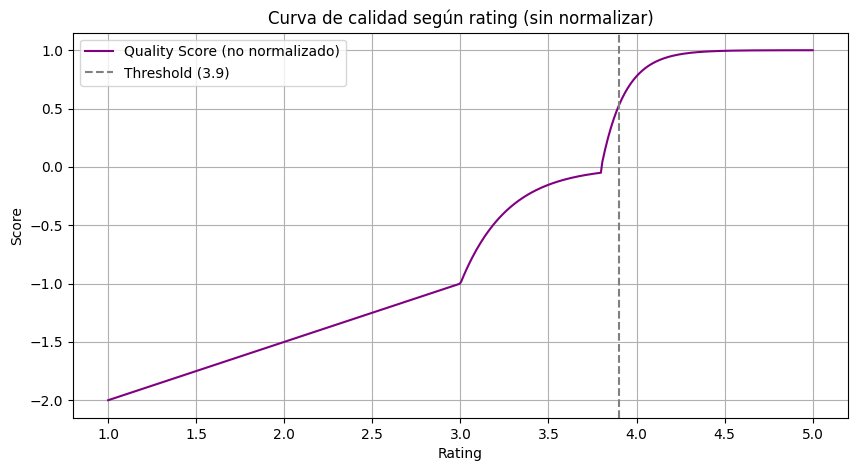

In [111]:
import numpy as np
import matplotlib.pyplot as plt

def curve_function_final(x):
    if x >= 3.8:
        # Sigmoide: f(3.9) = 0, f(5.0) ≈ 1
        normalized_x = (x - 3.8) / (5.0 - 3.8)
        return 1 - np.exp(-9 * normalized_x)
    
    elif x >= 3.0:
        # Caída de 0 a -1 (pequeña al inicio, más grande al final)
        t = (x - 3.0) / (3.8 - 3.0)  # t va de 0 a 1
        return - np.exp(-3 * t)
    
    else:
        # Lineal: f(3.0) = -1, f(1.0) = -2
        return 0.5 * (x - 3) - 1

# Crear array de ratings
ratings = np.linspace(1.0, 5.0, 500)
scores = [curve_function_final(r) for r in ratings]

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(ratings, scores, label='Quality Score (no normalizado)', color='purple')
plt.axvline(3.9, linestyle='--', color='gray', label='Threshold (3.9)')
plt.title("Curva de calidad según rating (sin normalizar)")
plt.xlabel("Rating")
plt.ylabel("Score")
plt.grid(True)
plt.legend()
plt.show()


In [40]:
user_input

{'meal': 'Costillas de Cerdo BBQ',
 'main_pairing': 'pork',
 'pairing_list': ['pork', 'spicy food'],
 'grape_list': ['Malbec'],
 'precio_min': 1,
 'precio_max': 18,
 'tastes': {'body': [np.float64(0.6567), np.float64(0.7888)],
  'tannins': [np.float64(0.285), np.float64(0.3264)],
  'sweetness': [np.float64(0.2181), np.float64(0.4248)],
  'acidity': [np.float64(0.359475), np.float64(0.40364999999999995)]},
 'tastes_label': {'body': 'intenso',
  'tannins': 'moderado',
  'sweetness': 'intenso',
  'acidity': 'moderado'},
 'weights': {'price_quality': 0,
  'wine_popularity': 1,
  'user_similarity': 0,
  'main_pairing': 0}}

In [41]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)
wine_base.sort_values(by="wine_score")

,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,sweetness,acidity,style,alcohol,image,ageing,black fruit,citrus,dried fruit,earthy,floral,oaky,red fruit,spices,tree fruit,tropical,vegetal,yeasty,any junk food will do,aperitif,appetizers and snacks,beef,blue cheese,cured meat,"game (deer, venison)",goat's milk cheese,lamb,lean fish,mature and hard cheese,mild and soft cheese,mushrooms,pasta,pork,poultry,"rich fish (salmon, tuna etc)",shellfish,spicy food,veal,vegetarian,Cabernet Franc,Cabernet Sauvignon,Chardonnay,Malbec,Merlot,Petit Verdot,Pinot Noir,Shiraz/Syrah,Agrelo,Argentina,Brazil,Cafayate Valley,Calchaqui Valley,Campanha,Famatina,Gualtallary,La Consulta,La Rioja,Las Compuertas,Lujan de Cuyo,Lunlunta,Maipu,Mendoza,Paraje Altamira,Patagonia,Pedernal Valley,Perdriel,Rio Grande do Sul,Rio Negro,Salta,San Carlos,San Juan,San Rafael,Serra Gaúcha,Tulum Valley,Tunuyán,Tupungato,Uco Valley,Vale dos Vinhedos,Vista Flores,Otras Uvas,wine_score
411,https://www.vivino.com/luis-segundo-correas-va...,Valle Las Acequias Malbec Oak,2021.0,Luis Segundo Correas,4.1,26.0,15.99,0.6185,0.2612,0.1448,0.3897,Argentinian Mendoza Malbec Red,0.1402,https://images.vivino.com/thumbs/VwuSMWEPR6aJ9...,0.0000,0.2785,0.0063,0.0190,0.1013,0.0063,0.4304,0.1013,0.0380,0.0063,0.0000,0.0000,0.0127,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0
548,https://www.vivino.com/casir-dos-santos-reserv...,Reserve Malbec,2016.0,Casir dos Santos,3.9,25.0,17.84,0.6431,0.4120,0.1595,0.3606,Argentinian Mendoza Malbec Red,0.1402,https://images.vivino.com/thumbs/0P-ENGWkTH26z...,0.0000,0.1875,0.0000,0.0000,0.3125,0.0000,0.4375,0.0000,0.0000,0.0000,0.0000,0.0625,0.0000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0
617,https://www.vivino.com/romulo-malbec/w/8767674...,Malbec,2019.0,Rómulo,3.9,25.0,17.84,0.5625,0.3045,0.2171,0.3364,Argentinian Mendoza Malbec Red,0.1402,https://images.vivino.com/thumbs/vftWGm9nS3ieJ...,0.0000,0.0000,0.0000,0.0000,0.3333,0.0000,0.6667,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0
627,https://www.vivino.com/tupa-malbec/w/7536798?y...,Malbec,2023.0,Tupã,3.9,25.0,14.69,0.6557,0.1933,0.0492,0.3341,Argentinian Mendoza Malbec Red,0.1402,https://images.vivino.com/thumbs/pdgFigbpSJih1...,0.0000,0.2308,0.0000,0.0000,0.1538,0.0000,0.1538,0.3077,0.1538,0.0000,0.0000,0.0000,0.0000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0
686,https://www.vivino.com/sur-de-los-andes-malbec...,Malbec,2022.0,Sur de Los Andes,3.8,25.0,15.74,0.6540,0.2333,0.1179,0.3534,Argentinian Mendoza Malbec Red,0.1402,https://images.vivino.com/thumbs/PYWPZBXAQ9yYa...,0.0204,0.4286,0.0000,0.0102,0.0816,0.0204,0.2755,0.1020,0.0408,0.0000,0.0000,0.0000,0.0204,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1790,https://www.vivino.com/antigal-uno-malbec/w/11...,UNO Malbec,2019.0,Antigal,3.9,1972.0,16.99,0.6406,0.2877,0.1670,0.3743,Argentinian Mendoza Malbec Red,0.1390,https://image

In [45]:
wine_base["wine_score"].value_counts()

wine_score
0.0    58
1.0    21
0.8    12
0.3    11
0.9    10
       ..
0.6     8
0.4     8
0.1     7
0.2     5
0.7     4
Name: count, Length: 11, dtype: int64

In [73]:
df = user.wine_df
tra_df = user._df_group_other_grapes(df, 8, True)
tra_df = user._score_wines(tra_df, user_input)
user_choice = user.simulate_user_choice(tra_df, user_input)
user_choice["user_choices"]

,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,sweetness,...,San Rafael,Serra Gaúcha,Tulum Valley,Tunuyán,Tupungato,Uco Valley,Vale dos Vinhedos,Vista Flores,Otras Uvas,wine_score
114,https://www.vivino.com/el-enemigo-cabernet-fra...,Cabernet Franc,2021.0,El Enemigo,4.3,1995.0,29.39,0.5304,0.4773,0.1825,...,0,0,0,0,0,0,0,0,0.0,0.868077
1228,https://www.vivino.com/el-enemigo-cabernet-fra...,Cabernet Franc,2019.0,El Enemigo,4.3,5542.0,26.99,0.5304,0.4773,0.1825,...,0,0,0,0,0,0,0,0,0.0,0.863406
1229,https://www.vivino.com/el-enemigo-cabernet-fra...,Cabernet Franc,2015.0,El Enemigo,4.3,4308.0,26.99,0.5304,0.4773,0.1825,...,0,0,0,0,0,0,0,0,0.0,0.863406
186,https://www.vivino.com/el-enemigo-cabernet-fra...,Cabernet Franc,2020.0,El Enemigo,4.2,2715.0,26.99,0.5304,0.4773,0.1825,...,0,0,0,0,0,0,0,0,0.0,0.850091
276,https://www.vivino.com/bressia-monteagrelo-cab...,Monteagrelo Cabernet Franc,2018.0,Bressia,4.1,1137.0,26.24,0.4839,0.4693,0.2796,...,0,0,0,0,0,0,0,0,0.0,0.849868
1530,https://www.vivino.com/carmelo-patti-cabernet-...,Cabernet Franc,2018.0,Carmelo Patti,4.1,261.0,29.99,0.4567,0.4681,0.2216,...,0,0,0,0,0,0,0,0,0.0,0.827177
274,https://www.vivino.com/catena-appellation-san-...,Appellation San Carlos Cabernet Franc,2019.0,Catena,4.1,1491.0,25.00,0.4528,0.5476,0.1043,...,0,0,0,0,0,1,0,0,0.0,0.824492
1461,https://www.vivino.com/catena-appellation-san-...,Appellation San Carlos Cabernet Franc,2018.0,Catena,4.1,1610.0,25.00,0.4528,0.5476,0.1043,...,0,0,0,0,0,1,0,0,0.0,0.824492
1501,https://www.vivino.com/zaha-toko-vineyard-cabe...,Toko Vineyard Cabernet Franc,2019.0,Zaha,4.1,468.0,29.49,0.5260,0.4812,0.2437,...,0,0,0,0,0,0,0,0,0.0,0.820978
1273,https://www.vivino.com/alpasion-grand-cabernet...,Grand Cabernet Franc,2016.0,Alpasión,4.3,427.0,33.95,0.5473,0.5577,0.0827,...,0,0,0,0,0,1,0,0,0.0,0.819481


In [97]:
user.simulate_like(user_choice["selected_wine"])

(1, np.float64(0.8768752792544581))